# 04_Math_Intuition.ipynb

This notebook explains **why Elastic Net works mathematically**, what every formula means, and how its hyperparameters affect the model.

---

# Final Formula(s)

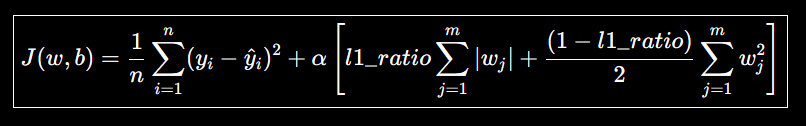

This is the **scikit-learn formulation**.

---

## Breaking it into parts

### Part 1 — Mean Squared Error (Prediction Error)

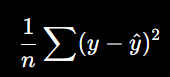


Smaller is better.

---

### Part 2 — L1 Penalty

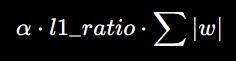

Encourages coefficients to become exactly **zero**.

This performs **feature selection**.

---

### Part 3 — L2 Penalty

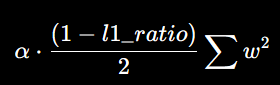

Encourages coefficients to become **small**.

This improves stability and reduces overfitting.

---

## Equivalent Conceptual Formula

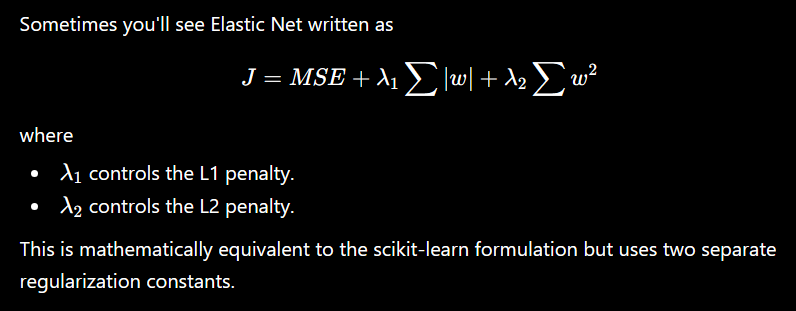

---

# Meaning of Every Symbol

| Symbol     | Meaning                             |
| ---------- | ----------------------------------- |
| (X)        | Feature matrix                      |
| (y)        | Actual target values                |
| (\hat y)   | Predicted values                    |
| (w)        | Coefficient vector                  |
| (b)        | Intercept (bias)                    |
| (n)        | Number of training samples          |
| (m)        | Number of features                  |
| (\alpha)   | Overall regularization strength     |
| (l1_ratio) | Balance between L1 and L2 penalties |
| (J)        | Total loss function                 |

---

# Why This Formula Works

Let's understand each part separately.

---

## Step 1 — Without Regularization

Linear Regression minimizes only

**`MSE`**

Example

Suppose

```text
Area coefficient = 120
```

Even if such a large value isn't necessary, Linear Regression has no reason to reduce it as long as it lowers the training error.

This can lead to overfitting.

---

## Step 2 — Add L2 Penalty

Now the objective becomes

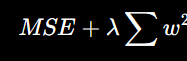

Large coefficients become expensive.

Example

```text
Coefficient

120

↓

90

↓

60

↓

40
```

The model still uses every feature, but with smaller coefficients.

---

## Step 3 — Add L1 Penalty

Now the objective becomes

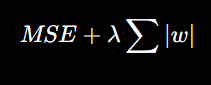

Example

```text
Coefficient

12

↓

7

↓

2

↓

0
```

Once a coefficient reaches zero, the corresponding feature is removed.

---

## Step 4 — Combine Both

Elastic Net minimizes

```text
Prediction Error

+

Shrink Large Coefficients

+

Remove Unimportant Features
```

This creates a model that is both **stable** and **sparse**.

---

# Geometry Intuition

Geometry gives one of the best ways to understand why Ridge, Lasso, and Elastic Net behave differently.

Imagine the horizontal axis is coefficient (w_1) and the vertical axis is coefficient (w_2).

---

## Linear Regression

There is **no restriction** on where the solution can lie.

```text
                w₂

                 ↑
                 │
                 ●
                 │
                 │
─────────────────┼────────────→ w₁
```

The optimizer chooses the point with the lowest MSE.

---

## Ridge Regression

The L2 penalty creates a **circular (or spherical in higher dimensions)** constraint.

```text
              w₂

               ↑
            ◜─────◝
          ◜         ◝
         │     ●     │
          ◟         ◞
            ◟─────◞
────────────────────────→ w₁
```

A circle has **no sharp corners**, so the optimal point rarely lands exactly on an axis.

Therefore,

```text
Almost no coefficients become zero.
```

---

## Lasso Regression

The L1 penalty creates a **diamond-shaped** constraint.

```text
               w₂

                ↑
                ♦
              ◢   ◣
            ◢       ◣
              ◥   ◤
                ♦
────────────────────────→ w₁
```

Notice the **sharp corners**.

These corners lie on the axes.

The optimizer often lands on a corner.

That means

```text
w₁ = 0

or

w₂ = 0
```

Hence feature selection.

---

## Elastic Net

Elastic Net combines both constraints.

The shape is **between a circle and a diamond**.

```text
                w₂

                 ↑
            ◜──♦──◝
         ◜           ◝
        │      ●      │
         ◟           ◞
            ◟──♦──◞
────────────────────────→ w₁
```

This shape has

* Rounded edges (from Ridge)
* Some sharpness (from Lasso)

Result:

* Some coefficients become zero.
* Correlated features are less likely to be discarded aggressively.

---

## Why does Elastic Net keep correlated features?

Suppose

```text
Area
Living Area
Total Area
```

All are highly correlated.

### Lasso

May keep only

```text
Area
```

and discard the others.

---

### Ridge

Keeps all three.

---

### Elastic Net

Often keeps all three but shrinks their coefficients.

Example

```text
Area          0.82
Living Area   0.74
Total Area    0.68
```

This is called the **grouping effect**.

It is one of Elastic Net's biggest advantages.

---

# Optimization Intuition

Unlike Ordinary Least Squares, Elastic Net does **not** have a simple closed-form solution.

Why?

The L1 term contains the absolute value:

**`|w|`**

The absolute value function is **not differentiable at zero**.

Because of this, the normal equation cannot be used.

---

## How is Elastic Net optimized?

Scikit-learn uses the **Coordinate Descent** algorithm by default.

The idea:

Instead of updating **all coefficients together**, update **one coefficient at a time** while keeping the others fixed.

```text
Start

↓

Update w₁

↓

Update w₂

↓

Update w₃

↓

...

↓

Repeat Until Convergence
```

This works efficiently for objectives containing L1 penalties.

> **Note:** We'll discuss `selection`, `max_iter`, `tol`, `warm_start`, and why Coordinate Descent is used in detail in **06_Scikit_Learn.ipynb**, just as we did for Ridge and Lasso.

---

# Hyperparameter Effect

Elastic Net has two primary hyperparameters.

---

## 1. alpha

Controls the **overall regularization strength**.

### Very Small alpha

```python
alpha = 0.0001
```

Behavior

* Very weak regularization
* Similar to Linear Regression
* Low bias
* High variance
* Higher risk of overfitting

---

### Medium alpha

```python
alpha = 1
```

Balanced regularization.

Usually a good starting point.

---

### Large alpha

```python
alpha = 100
```

Behavior

* Strong regularization
* Small coefficients
* Higher bias
* Lower variance
* Risk of underfitting

---

### Summary

| alpha ↑          | Effect       |
| ---------------- | ------------ |
| Coefficients     | Smaller      |
| Model Complexity | Decreases    |
| Bias             | Increases    |
| Variance         | Decreases    |
| Overfitting      | Decreases    |
| Underfitting     | May increase |

---

## 2. l1_ratio

Controls the balance between L1 and L2 penalties.

---

### `l1_ratio = 0`

Equivalent to Ridge Regression.

```text
L1 = 0%

L2 = 100%
```

---

### `l1_ratio = 0.25`

Mostly Ridge.

```text
L1 = 25%

L2 = 75%
```

---

### `l1_ratio = 0.5`

Balanced Elastic Net.

```text
L1 = 50%

L2 = 50%
```

---

### `l1_ratio = 0.75`

Mostly Lasso.

```text
L1 = 75%

L2 = 25%
```

---

### `l1_ratio = 1`

Equivalent to Lasso Regression.

```text
L1 = 100%

L2 = 0%
```

---

### Visual intuition

```text
Ridge  <------------------------->  Lasso

0        0.25      0.5      0.75      1

        Elastic Net Region
```

---

### Effect on coefficients

| l1_ratio | Behavior                                        |
| -------- | ----------------------------------------------- |
| 0        | Shrinks all coefficients, none become zero      |
| 0.25     | Mostly shrinking, little feature selection      |
| 0.5      | Good balance of shrinkage and feature selection |
| 0.75     | More feature selection                          |
| 1        | Maximum feature selection (Lasso)               |

---

# Time Complexity

Assume

* (n) = number of samples
* (m) = number of features
* (T) = number of Coordinate Descent iterations until convergence

Approximate training complexity:

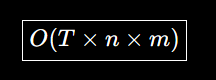

Why?

In each iteration:

* The algorithm cycles through the features.
* Updating each coefficient requires computations involving the training samples.

Prediction complexity for one sample:

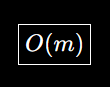

since it computes a weighted sum of all features.

---

# Space Complexity

The model stores:

* Training data (during fitting)
* Coefficient vector
* Intercept
* Temporary optimization variables

Approximate space complexity:

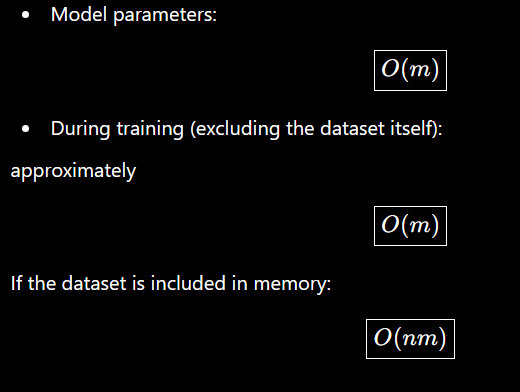


---

# Key Takeaways

* Elastic Net minimizes **prediction error + L1 penalty + L2 penalty**.
* The **L1 penalty** produces sparsity by setting some coefficients to zero.
* The **L2 penalty** shrinks coefficients and improves stability.
* `alpha` controls **how much** regularization is applied overall.
* `l1_ratio` controls **the balance** between L1 and L2.
* Geometrically, Elastic Net combines the properties of Ridge's circular constraint and Lasso's diamond-shaped constraint.
* Because of the L1 term, Elastic Net uses **Coordinate Descent** instead of the normal equation.

---

**Notebook 04 is complete.**
